In [423]:

# Simplified PyTorch Prompt (GAN + Classifier + ROC)
# Complete end-to-end implementation for MNIST (binary: 0 vs 1)

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix

In [424]:

# ----------------------------
# Global configuration & state
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_train = None
y_train = None
x_test = None
y_test = None


In [425]:

# ----------------------------
# Discriminator
# ----------------------------
def discriminator() -> torch.nn.Module:
    model = nn.Sequential(
        nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # 28 -> 14
        nn.LeakyReLU(0.2, inplace=True),
        nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 14 -> 7
        nn.BatchNorm2d(64),
        nn.LeakyReLU(0.2, inplace=True),
        nn.Flatten(),
        nn.Linear(64 * 7 * 7, 1),
        nn.Sigmoid(),
    )
    return model.to(device)

In [426]:

# ----------------------------
# Generator (random_vector = 32)
# ----------------------------
class _Unflatten(nn.Module):
    def __init__(self, channels, height, width):
        super().__init__()
        self.c = channels
        self.h = height
        self.w = width
    def forward(self, x):
        return x.view(x.size(0), self.c, self.h, self.w)

def generator(random_vector = 32) -> torch.nn.Module:
    model = nn.Sequential(
        nn.Linear(random_vector, 128 * 7 * 7),
        nn.ReLU(inplace=True),
        _Unflatten(128, 7, 7),
        nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 7 -> 14
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),    # 14 -> 28
        nn.Sigmoid(),  # output in [0,1], shape (1,28,28)
    )
    return model.to(device)



In [427]:
# ----------------------------
# Classifier (2 logits)
# ----------------------------
def classifier() -> torch.nn.Module:
    model = nn.Sequential(
        nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),  # 28 -> 14
        nn.Flatten(),
        nn.Linear(32 * 14 * 14, 64),
        nn.ReLU(inplace=True),
        nn.Linear(64, 2),  # 2 logits, no softmax
    )
    return model.to(device)


In [428]:
# ----------------------------
# Obtain dataset
# ----------------------------
def obtain_dataset(selected_class: int, number_of_images: int):
    transform = transforms.Compose([
        transforms.ToTensor(),        # produces [0,1] float tensor
    ])
    train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

    # Filter by selected_class
    train_mask = train_ds.targets == selected_class
    test_mask  = test_ds.targets == selected_class

    x_train_class = train_ds.data[train_mask][:int(number_of_images*(1-test_size)),:,:].unsqueeze(1).float() / 255.0  # (N,1,28,28) in [0,1]
    y_train_class = train_ds.targets[train_mask][:int(number_of_images*(1-test_size))].long()

    x_test_class  = test_ds.data[test_mask][:int(number_of_images*test_size),:,:].unsqueeze(1).float() / 255.0
    y_test_class  = test_ds.targets[test_mask][:int(number_of_images*test_size)].long()

    # Limit number_of_images (for train only, as requested)
    if number_of_images is not None:
        x_train_class = x_train_class[:number_of_images]
        y_train_class = y_train_class[:number_of_images]

    return x_train_class, y_train_class, x_test_class, y_test_class

In [429]:
# ----------------------------
# Build and train classifier (+ ROC)
# ----------------------------
def build_and_train_classifier(epochs: int, batch_size: int):
    global x_train, y_train, x_test, y_test

    model = classifier()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=1e-3)

    train_loader = DataLoader(TensorDataset(x_train.to(device), y_train.to(device)),
                              batch_size=batch_size, shuffle=True)

    # Train
    model.train()
    for epoch in range(epochs):
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
        print(f"Classifier | Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f}")

    # Eval + ROC
    model.eval()
    with torch.no_grad():
        logits = model(x_test.to(device))  # (N,2)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()  # probability of class 1
    y_pred = np.argmax(logits, axis=-1)

    y_true = y_test.cpu().numpy()

    acc_score = accuracy_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, probs, pos_label=1)
    roc_auc = auc(fpr, tpr)
    print(f"Classifier | Test ROC AUC: {roc_auc:.4f}")

    plt.figure(figsize=(5, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], "k--", label="Chance")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Class 1 probability)")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
    print(f"accuracy :{acc_score:.4f}")
    print("confusion matrix" ,confusion_matrix(y_true, y_pred))
    return model




In [430]:
# ----------------------------
# Build and train GAN
# ----------------------------
def build_and_train_GAN(epochs: int, batch_size: int):
    global x_train, trained_generator

    D = discriminator()
    G = generator()

    criterion = nn.BCELoss()
    opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))

    # Use current training set (digits 0) as real images
    real_loader = DataLoader(TensorDataset(x_train_0.to(device), y_train_0.to(device)),
                             batch_size=batch_size, shuffle=True)


    for epoch in range(epochs):
        for xb, _ in real_loader:
            bs = xb.size(0)

            # -----------------
            # Train Discriminator
            # -----------------
            D.train()
            opt_D.zero_grad()

            # Real
            real_labels = torch.ones(bs, 1, device=device)
            pred_real = D(xb)
            loss_real = criterion(pred_real, real_labels)

            # Fake
            z = torch.randn(bs, random_vector, device=device)
            fake = G(z)
            fake_labels = torch.zeros(bs, 1, device=device)
            pred_fake = D(fake.detach())
            loss_fake = criterion(pred_fake, fake_labels)

            loss_D = loss_real + loss_fake
            loss_D.backward()
            opt_D.step()

            # -----------------
            # Train Generator
            # -----------------
            G.train()
            opt_G.zero_grad()

            z = torch.randn(bs, random_vector, device=device)
            fake = G(z)
            target = torch.ones(bs, 1, device=device)  # try to fool D
            pred = D(fake)
            loss_G = criterion(pred, target)
            loss_G.backward()
            opt_G.step()

        print(f"GAN | Epoch {epoch+1}/{epochs} | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

    trained_generator = G  # store globally for create_fake_images
    return G


In [431]:
# ----------------------------
# Create fake images
# ----------------------------
def create_fake_images(number_of_images: int):
    global trained_generator
    assert trained_generator is not None, "Generator not trained yet."

    trained_generator.eval()
    with torch.no_grad():
        z = torch.randn(number_of_images, random_vector, device=device)
        fake_imgs = trained_generator(z)  # (N,1,28,28), [0,1]
    return fake_imgs.cpu().view(-1, 1, 28, 28)


In [432]:
# [1] Define the hyper-parameters
test_size = 0.1  # used in main logic below
trained_generator = None  # set after build_and_train_GAN
image_size = 28
random_vector = 32

In [433]:
# [2] Obtain dataset '0' and '1' from mnist
x_train_0, y_train_0, x_test_0, y_test_0 = obtain_dataset(selected_class=0, number_of_images=100)
x_train_1, y_train_1, x_test_1, y_test_1 = obtain_dataset(selected_class=1, number_of_images=1000)
print("class 0: ", x_train_0.shape, x_test_0.shape, y_train_0.shape, y_test_0.shape)
print("class 1: ", x_train_1.shape, x_test_1.shape, y_train_1.shape, y_test_1.shape)

class 0:  torch.Size([90, 1, 28, 28]) torch.Size([10, 1, 28, 28]) torch.Size([90]) torch.Size([10])
class 1:  torch.Size([900, 1, 28, 28]) torch.Size([100, 1, 28, 28]) torch.Size([900]) torch.Size([100])


In [434]:
# [3] Create imbalanced dataset by merging class '0' and '1'
x_train = torch.cat((x_train_0, x_train_1))
x_test = torch.cat((x_test_0, x_test_1))
y_train = torch.cat((y_train_0, y_train_1))
y_test = torch.cat((y_test_0, y_test_1))

print("merged 0 and 1 data: ", x_train.shape, x_test.shape, y_train.shape, y_test.shape)


merged 0 and 1 data:  torch.Size([990, 1, 28, 28]) torch.Size([110, 1, 28, 28]) torch.Size([990]) torch.Size([110])


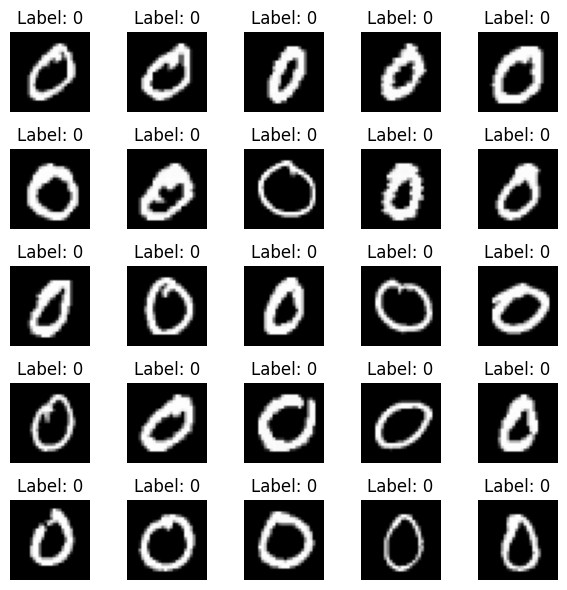

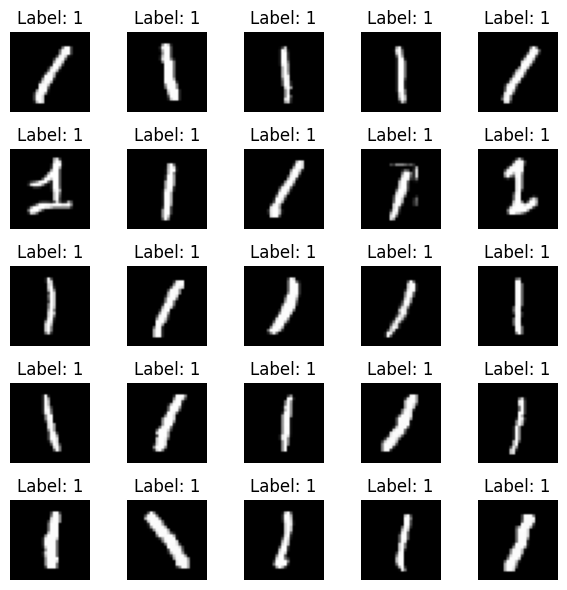

In [435]:
from matplotlib import pyplot as plt

# Plot the images
fig, axes = plt.subplots(5, 5, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train_0[i][0], cmap='gray')
    ax.set_title(f"Label: {y_train_0[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()
# Plot the images
fig, axes = plt.subplots(5, 5, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train_1[i][0], cmap='gray')
    ax.set_title(f"Label: {y_train_1[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

Classifier | Epoch 1/5 | Loss: 0.3848
Classifier | Epoch 2/5 | Loss: 0.3127
Classifier | Epoch 3/5 | Loss: 0.3063
Classifier | Epoch 4/5 | Loss: 0.1903
Classifier | Epoch 5/5 | Loss: 0.2979
Classifier | Test ROC AUC: 1.0000


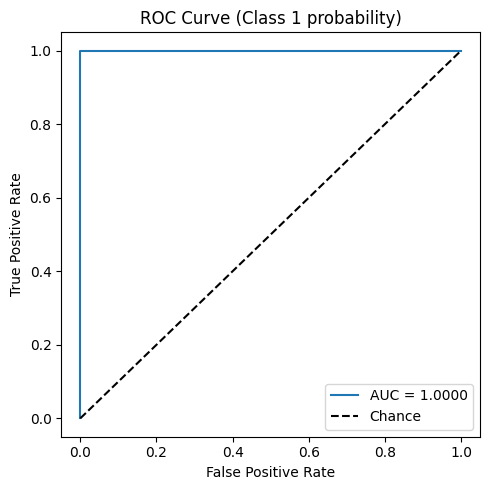

accuracy :0.9091
confusion matrix [[  0  10]
 [  0 100]]


Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=6272, out_features=64, bias=True)
  (5): ReLU(inplace=True)
  (6): Linear(in_features=64, out_features=2, bias=True)
)

In [436]:
# [4] Build, train, and test a classifier
# TODO: call function build_and_train_classifier with epoch 5 and batch size 32, print the output
# ...

In [437]:
# [5] Build and train GAN
# TODO: call function build_and_train_GAN with epoch 20 and batch size 32, save the output to a variable named 'Gen'
# ...

GAN | Epoch 1/20 | D Loss: 0.9089 | G Loss: 1.1879
GAN | Epoch 2/20 | D Loss: 0.5982 | G Loss: 1.5862
GAN | Epoch 3/20 | D Loss: 0.4630 | G Loss: 1.7508
GAN | Epoch 4/20 | D Loss: 0.3322 | G Loss: 2.0796
GAN | Epoch 5/20 | D Loss: 0.3098 | G Loss: 2.2164
GAN | Epoch 6/20 | D Loss: 0.2463 | G Loss: 2.3454
GAN | Epoch 7/20 | D Loss: 0.1754 | G Loss: 2.6791
GAN | Epoch 8/20 | D Loss: 0.1762 | G Loss: 2.7396
GAN | Epoch 9/20 | D Loss: 0.1638 | G Loss: 2.7792
GAN | Epoch 10/20 | D Loss: 0.1513 | G Loss: 2.7578
GAN | Epoch 11/20 | D Loss: 0.1534 | G Loss: 2.8452
GAN | Epoch 12/20 | D Loss: 0.1411 | G Loss: 2.9226
GAN | Epoch 13/20 | D Loss: 0.1418 | G Loss: 2.9768
GAN | Epoch 14/20 | D Loss: 0.1122 | G Loss: 3.1275
GAN | Epoch 15/20 | D Loss: 0.1413 | G Loss: 3.2153
GAN | Epoch 16/20 | D Loss: 0.0997 | G Loss: 2.8876
GAN | Epoch 17/20 | D Loss: 0.1239 | G Loss: 3.2021
GAN | Epoch 18/20 | D Loss: 0.1662 | G Loss: 2.9871
GAN | Epoch 19/20 | D Loss: 0.1379 | G Loss: 2.8626
GAN | Epoch 20/20 | D

Sequential(
  (0): Linear(in_features=32, out_features=6272, bias=True)
  (1): ReLU(inplace=True)
  (2): _Unflatten()
  (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU(inplace=True)
  (6): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (7): Sigmoid()
)

In [438]:
# [6] Create fake data for class '0'
number_of_fake_images = 900
# TODO: call function create_fake_images with given number of fake images, save the output to a variable named 'fake_images'
# ...

torch.Size([900, 1, 28, 28])


torch.Size([110, 1, 28, 28]) torch.Size([900, 1, 28, 28])


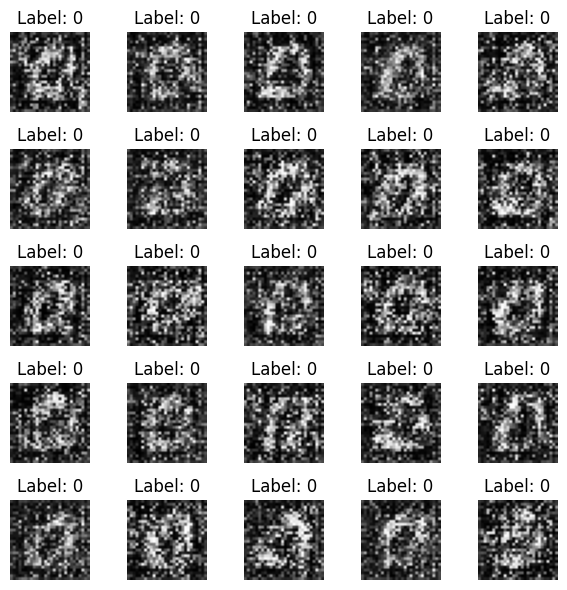

In [439]:
from matplotlib import pyplot as plt

# Create a DataLoader for the fake images
print(x_test.shape, fake_images.shape)

# Plot the images
fig, axes = plt.subplots(5, 5, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(fake_images[i][0], cmap='gray')
    ax.set_title(f"Label: {0}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [440]:
# [7] Merge fake data with the original data
# Split fake images into train/test and augment
train_num = int(number_of_fake_images * (1 - test_size))
test_num = int(number_of_fake_images * test_size)

x_train = torch.cat((x_train, fake_images[:train_num]))
x_test = torch.cat((x_test, fake_images[train_num:]))

# Label fake images as class 0 (per given logic)
y_train = torch.cat((y_train, torch.zeros(train_num, dtype=torch.long)))
y_test = torch.cat((y_test, torch.zeros(test_num, dtype=torch.long)))
print("final data: ", x_train.shape, x_test.shape, y_train.shape, y_test.shape)

final data:  torch.Size([1800, 1, 28, 28]) torch.Size([200, 1, 28, 28]) torch.Size([1800]) torch.Size([200])


In [441]:
# [8] Build, train, and test a classifier
# TODO: call function build_and_train_classifier with epoch 5 and batch size 32, print the output
# ...
# Retrain classifier with augmented data